In [4]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.ComplexDemodTest import CD_f0_schedule
from src.spectra import sensor_spectra

In [3]:
import matplotlib.pyplot as plt

# ---- load data ----- #
df1 = pd.read_parquet('../data_interim/df1.parquet')
df6 = pd.read_parquet('../data_interim/df6.parquet')



# --- 1. Run the synchronized pipeline ---
# Using the function you provided to drive df1 (nearshore) with df6 (offshore)
start_dt = pd.Timestamp("2008-01-13 18:00:00")
end_dt = pd.Timestamp("2008-01-14 06:00:00")
cd_results = CD_f0_schedule(df1, df6, start_dt, end_dt)

# --- 2. Extract IG Energy using your sensor_spectra function ---
# Assuming sensor_spectra returns a DataFrame/Series with an 'IG_energy' column
ig_stats = sensor_spectra(df1, start_dt, end_dt) 

# Resample CD results to match the spectral processing window (usually hourly)
hourly_ss = cd_results['A'].resample('1H').mean()
hourly_period = 1 / cd_results['f0_used'].resample('1H').mean()

# --- 3. Visualization ---
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2)

# Top: Time-series verification (Zoomed in to 15 mins)
ax1 = fig.add_subplot(gs[0, :])
zoom_mask = (cd_results.index >= "2008-01-13 22:00:00") & (cd_results.index <= "2008-01-13 22:15:00")
zoom_df = cd_results.loc[zoom_mask]

ax1.plot(zoom_df.index, zoom_df['x_ss'], color='lightgray', label='Nearshore SS (Raw)')
ax1.plot(zoom_df.index, zoom_df['A'], color='blue', linewidth=2, label='CD Envelope (Offshore Driven)')
ax1.set_title("Nearshore Complex Demodulation Verification (df1)")
ax1.set_ylabel("Amplitude (m)")
ax1.legend()

# Bottom: IG Energy vs SS Envelope Scatter
ax2 = fig.add_subplot(gs[1, :])
sc = ax2.scatter(ig_stats['IG_energy'], hourly_ss, c=hourly_period, cmap='viridis', edgecolors='k')
ax2.set_xlabel("Nearshore IG Energy (from sensor_spectra)")
ax2.set_ylabel("Nearshore SS Envelope Amplitude (A)")
ax2.set_title("Nearshore IG Energy vs. Sea-Swell Forcing")

cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label("Swell Period (s)")

plt.tight_layout()
plt.show()

/Users/isidorarojas/Desktop/DIRECTORY/2025/reef_runup/moku_PILOT/2026_Mark_Meetings/../src/ComplexDemodTest.py:83: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start=start, end=end, freq='1H')
/Users/isidorarojas/Desktop/DIRECTORY/2025/reef_runup/moku_PILOT/2026_Mark_Meetings/../src/ComplexDemodTest.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  f0_schedule = offshore_master['f0'].resample('1H').mean()


NameError: name 'sensor_spectra' is not defined

/Users/isidorarojas/Desktop/DIRECTORY/2025/reef_runup/moku_PILOT/2026_Mark_Meetings/../src/ComplexDemodTest.py:93: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start=start, end=end, freq='1H')


Text(0, 0.5, 'freq (hz)')

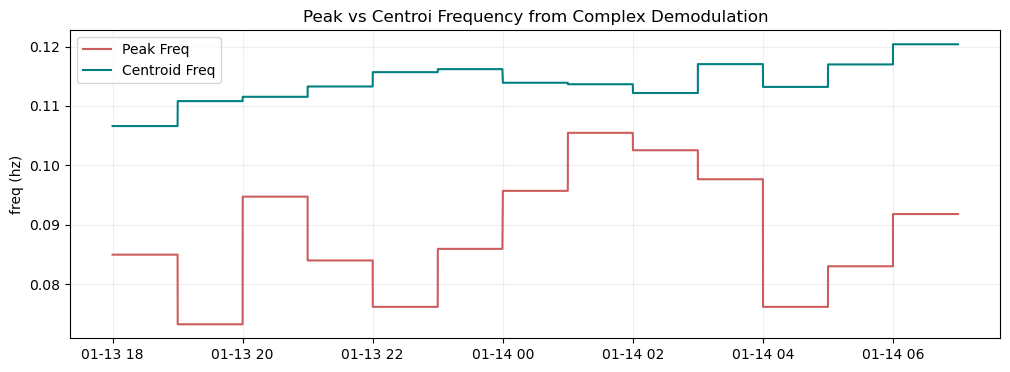

In [15]:
# ---- load data ----- #
df1 = pd.read_parquet('../data_interim/df1.parquet')
df6 = pd.read_parquet('../data_interim/df6.parquet')


# compute complex demodulation
start = pd.Timestamp("2008-01-13 18:00:00")
end = pd.Timestamp("2008-01-14 06:00:00")
cd1_peak = complex_demod_hourly(df1, start, end, f0='peak')
cd1_centroid = complex_demod_hourly(df1, start, end, f0='centroid')

plt.figure(figsize=(12,4))
plt.plot(cd1_peak.index, cd1_peak['f0_peak'], label='Peak Freq', color='IndianRed')
plt.plot(cd1_centroid.index, cd1_centroid['f0_centroid'], label='Centroid Freq', color='Teal')
plt.legend()
plt.grid(True, alpha=0.2)
plt.title('Peak vs Centroi Frequency from Complex Demodulation')
plt.ylabel('freq (hz)')

In [6]:
cd1_peak

,A,E,x_ss,f0_centroid,f0_peak
2008-01-13 18:00:00.000000000,0.004517,0.000020,0.000413,0.106608,0.084961
2008-01-13 18:00:01.000004608,0.007600,0.000058,0.035499,0.106608,0.084961
2008-01-13 18:00:01.999999232,0.018440,0.000340,0.072416,0.106608,0.084961
2008-01-13 18:00:03.000003840,0.028812,0.000830,0.098295,0.106608,0.084961
2008-01-13 18:00:03.999998208,0.038276,0.001465,0.095226,0.106608,0.084961
...,...,...,...,...,...
2008-01-14 06:59:55.999998208,0.011267,0.000127,0.000904,0.120377,0.091797
2008-01-14 06:59:57.000002816,0.007536,0.000057,-0.007585,0.120377,0.091797
2008-01-14 06:59:57.999997440,0.004656,0.000022,-0.018400,0.120377,0.091797
2008-01-14 06:59:59.000002048,0.003666,0.000013,-0.017046,0.120377,0.091797


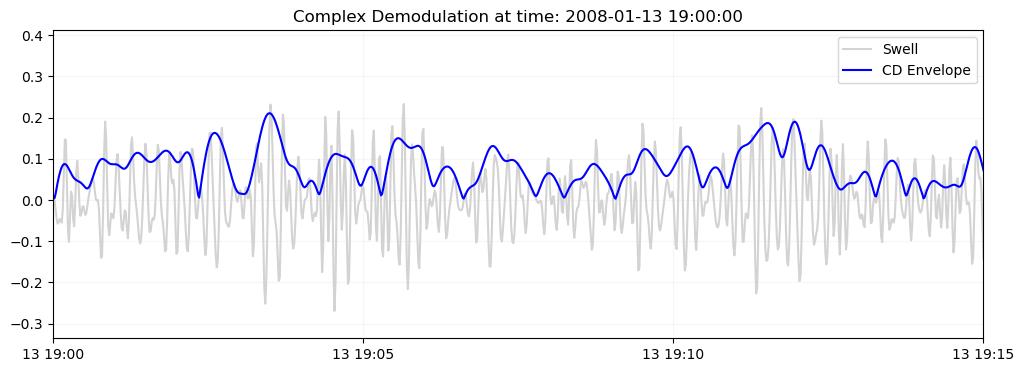

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cd1_peak.index, cd1_peak['x_ss'], color='lightgray', label='Swell')
ax.plot(cd1_peak.index, cd1_peak['A'], color='blue', label='CD Envelope')
time = pd.Timestamp('2008-01-13 19:00:00')
plt.xlim(time, time + pd.Timedelta(minutes=15))
plt.legend()
plt.grid(True, alpha=0.1)
plt.title(f'Complex Demodulation at time: {time}')
plt.show()

/Users/isidorarojas/Desktop/DIRECTORY/2025/reef_runup/moku_PILOT/2026_Mark_Meetings/../src/ComplexDemodTest.py:93: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start=start, end=end, freq='1H')


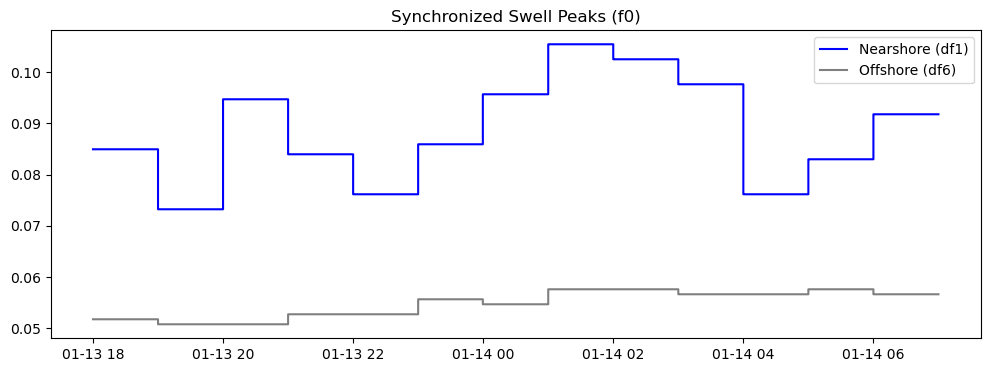

In [12]:
# Compare your two sensors (df1 and df6) with the tight limits
cd1 = complex_demod_hourly(df1, start, end, f_swell=(0.05, 0.2), f0='peak')
cd6 = complex_demod_hourly(df6, start, end, f_swell=(0.05, 0.2), f0='peak')

plt.figure(figsize=(12,4))
plt.step(cd1.index, cd1['f0_peak'], label='Nearshore (df1)', color='blue')
plt.step(cd6.index, cd6['f0_peak'], label='Offshore (df6)', color='black', alpha=0.5)
plt.title("Synchronized Swell Peaks (f0)")
plt.legend()
plt.show()

Using f0 from offshore sensor for nearshore complex demodulation. 

Since waves are broken by the time they reach the nearshore sensor, using the offshore sensor's f0 (peak frequency) may yield better results for complex demodulation.

In [19]:
cd6 = complex_demod_hourly(df6, start, end, f0='peak', f_swell=(0.05, 0.2))
f0_map = cd6['f0_peak'].resample('1H').mean()

/Users/isidorarojas/Desktop/DIRECTORY/2025/reef_runup/moku_PILOT/2026_Mark_Meetings/../src/ComplexDemodTest.py:93: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start=start, end=end, freq='1H')
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_37134/2159397291.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  f0_map = cd6['f0_peak'].resample('1H').mean()


In [ ]:
from src.bulk_parameters import Hs_band
from src.ComplexDemodTest import CD_f0_schedule
from src.spectra import sensor_spectra

window_len = 1024

# ---- load data ----- #
df1 = pd.read_parquet('../data_interim/df1.parquet')
df6 = pd.read_parquet('../data_interim/df6.parquet')

# complex demod with offshore driven f0
start_dt = pd.Timestamp("2008-01-13 18:00:00")
end_dt = pd.Timestamp("2008-01-14 06:00:00")
cd = CD_f0_schedule(df1, df6, start_dt, end_dt)

# compute ig energy from sensor 1 spectra
S1 = sensor_spectra(df1, nperseg=1024)
ig_band = (0.004, 0.04)
igHs = Hs_band(S1, ig_band[0], ig_band[1])

# Resample CD results to match the spectral time centers
# 4. Resample everything to the 17-min (1024s) spectral time centers
# This ensures we compare exactly what was happening in each 17-min burst
ss_17m = cd['A'].resample(window_len, label='left').mean()
T_17m = (1 / cd['f0_used']).resample(window_len, label='left').mean()

# Align IG height with the CD windows
# igHs already has centers at ~17min intervals due to nperseg=1024
ig_aligned = igHs.interp(time=ss_17m.index)

plt.plot(ig_aligned.time, ig_aligned.values)

/Users/isidorarojas/Desktop/DIRECTORY/2025/reef_runup/moku_PILOT/2026_Mark_Meetings/../src/ComplexDemodTest.py:83: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start=start, end=end, freq='1H')
/Users/isidorarojas/Desktop/DIRECTORY/2025/reef_runup/moku_PILOT/2026_Mark_Meetings/../src/ComplexDemodTest.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  f0_schedule = offshore_master['f0'].resample('1H').mean()


ValueError: Invalid frequency: 1024

In [11]:
IG_hourly

<xarray.DataArray 'Seta' (time: 13)> Size: 104B
array([1.00648663, 0.84263666, 0.84118362, 0.7291751 , 0.80510594,
       0.75213665, 0.82761815, 0.72665157, 0.71392848, 0.93991663,
       0.77432434, 0.58355829, 0.73652835])
Coordinates:
  * time     (time) datetime64[ns] 104B 2008-01-13T18:00:00 ... 2008-01-14T06...

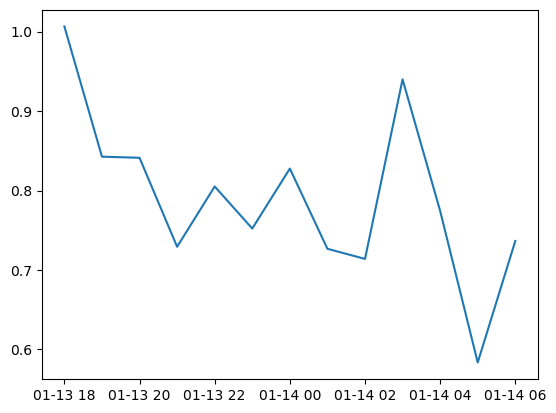

In [13]:
plt.plot(IG_hourly.time, IG_hourly.values)

/Users/isidorarojas/Desktop/DIRECTORY/2025/reef_runup/moku_PILOT/2026_Mark_Meetings/../src/ComplexDemodTest.py:83: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start=start, end=end, freq='1H')
/Users/isidorarojas/Desktop/DIRECTORY/2025/reef_runup/moku_PILOT/2026_Mark_Meetings/../src/ComplexDemodTest.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  f0_schedule = offshore_master['f0'].resample('1H').mean()
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_41523/4065993493.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_ss_amplitude = cd_results['A'].resample('1H').mean()
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_41523/4065993493.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_period = 1 / cd_results

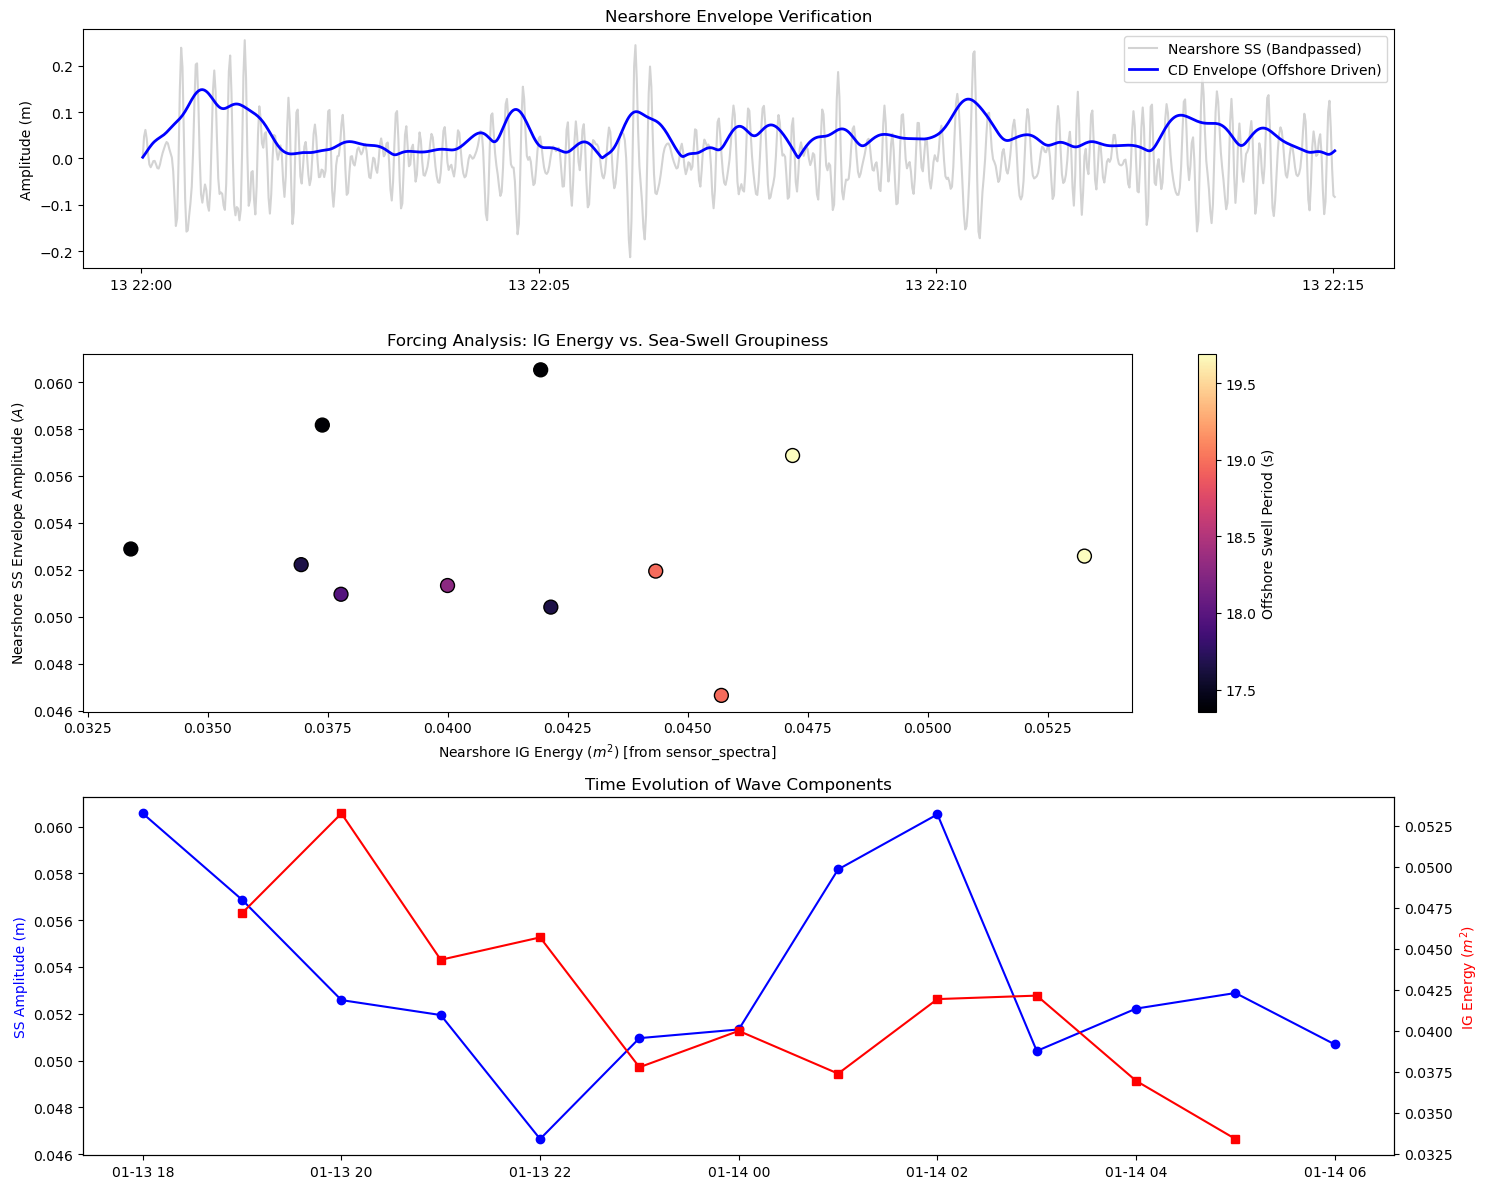

In [ ]:

# ---- load data ----- #
df1 = pd.read_parquet('../data_interim/df1.parquet')
df6 = pd.read_parquet('../data_interim/df6.parquet')

# complex demod with offshore driven f0
start_dt = pd.Timestamp("2008-01-13 18:00:00")
end_dt = pd.Timestamp("2008-01-14 06:00:00")

# Nearshore (df1) driven by Offshore (df6) frequencies
cd_results = CD_f0_schedule(df1, df6, start_dt, end_dt)

# compute ig energy from spectra
ds_spec = sensor_spectra(df1.loc[start_dt:end_dt], nperseg=4096)

# Define IG band (e.g., 0.004 to 0.04 Hz)
ig_mask = (ds_spec.frequency >= 0.004) & (ds_spec.frequency <= 0.04)
# Integrate Seta over the IG band to get energy (m^2)
ig_energy = ds_spec.Seta.sel(frequency=ig_mask).integrate("frequency")

# --- 3. Synchronize Hourly Data for Comparison ---
# Resample CD results to match the spectral time centers
hourly_ss_amplitude = cd_results['A'].resample('1H').mean()
hourly_period = 1 / cd_results['f0_used'].resample('1H').mean()

# Align the IG energy with our hourly amplitude
# (Using reindex or interp to ensure timestamps match exactly)
ig_aligned = ig_energy.interp(time=hourly_ss_amplitude.index)

# --- 4. Plotting ---
fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1.5, 1.5])

# Panel A: Time-series Verification (Zoomed 15-min)
ax1 = fig.add_subplot(gs[0])
zoom_start, zoom_end = "2008-01-13 22:00:00", "2008-01-13 22:15:00"
z_df = cd_results.loc[zoom_start:zoom_end]
ax1.plot(z_df.index, z_df['x_ss'], color='lightgray', label='Nearshore SS (Bandpassed)')
ax1.plot(z_df.index, z_df['A'], color='blue', linewidth=2, label='CD Envelope (Offshore Driven)')
ax1.set_title("Nearshore Envelope Verification")
ax1.set_ylabel("Amplitude (m)")
ax1.legend()

# Panel B: IG Energy vs SS Envelope Scatter
ax2 = fig.add_subplot(gs[1])
sc = ax2.scatter(ig_aligned, hourly_ss_amplitude, c=hourly_period, cmap='magma', s=100, edgecolors='k')
ax2.set_xlabel("Nearshore IG Energy ($m^2$) [from sensor_spectra]")
ax2.set_ylabel("Nearshore SS Envelope Amplitude ($A$)")
ax2.set_title("Forcing Analysis: IG Energy vs. Sea-Swell Groupiness")
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label("Offshore Swell Period (s)")

# Panel C: Evolution of Energy over Time
ax3 = fig.add_subplot(gs[2])
ax3.plot(hourly_ss_amplitude.index, hourly_ss_amplitude, color='blue', label='SS Envelope ($A$)', marker='o')
ax3_twin = ax3.twinx()
ax3_twin.plot(ig_aligned.time, ig_aligned, color='red', label='IG Energy', marker='s')
ax3.set_ylabel("SS Amplitude (m)", color='blue')
ax3_twin.set_ylabel("IG Energy ($m^2$)", color='red')
ax3.set_title("Time Evolution of Wave Components")

plt.tight_layout()
plt.show()